In [1]:
from typing import Annotated

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command
from dotenv import load_dotenv
from typing import TypedDict
from langchain_core.messages import BaseMessage
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint

In [2]:
load_dotenv()

True

In [7]:
# model = HuggingFaceEndpoint(
#     repo_id="mistralai/Mistral-7B-Instruct-v0.2",
#     task="text-generation"
# )

# llm = ChatHuggingFace(llm=model)

llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash')

In [4]:
class GraphState(TypedDict):

    question: str
    answer_eng : str
    answer_hin : str

In [5]:
def generate_answer(state: GraphState):

    prompt = f"""
    You are a helpful assistant that give answer of my question : Question: {state['question']}
"""
    
    response = llm.invoke(prompt).content

    return {'answer_eng': response}

In [8]:
def translate_text(state: GraphState):

    prompt = f"""
    You are helpful assistant that translate a given text from english to hindi.

    Text:
    {state['answer_eng']}
"""
    
    response = llm.invoke(prompt).content

    return {'answer_hin':response}


In [9]:
graph = StateGraph(GraphState)

graph.add_node('answer',generate_answer)
graph.add_node('translate',translate_text)

graph.add_edge(START,'answer')
graph.add_edge('answer','translate')
graph.add_edge('translate',END)

compiled_graph = graph.compile()

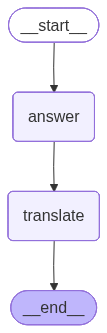

In [10]:
compiled_graph

In [11]:
compiled_graph.invoke({'question': "What is GenAI?"})

{'question': 'What is GenAI?',
 'answer_eng': "GenAI stands for **Generative Artificial Intelligence**.\n\nIn simple terms, GenAI is a type of artificial intelligence that can **create new, original content** rather than just analyzing or classifying existing data.\n\nHere's a breakdown of what that means:\n\n1.  **Generative:** Unlike traditional AI that might identify a cat in an image (discriminative AI), GenAI can *generate* a completely new image of a cat that has never existed before.\n2.  **Learns Patterns:** It works by being trained on vast amounts of existing data (text, images, audio, video, code, etc.). Through this training, it learns the underlying patterns, structures, and relationships within that data.\n3.  **Creates New Content:** Once it has learned these patterns, it can then use that knowledge to produce novel outputs that resemble the training data but are unique and original.\n\n**What kind of content can GenAI create?**\n\n*   **Text:** Articles, stories, poems,